# Banking Fraud Detection — Data Analysis

## 1. Setup & Imports
Loading required libraries for data manipulation, analysis, and visualization.

In [1]:
import os
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

## 2. Load Dataset

In [9]:
df = pd.read_csv("C:/Users/abhis/OneDrive/Documents/Banking Fraud Analytics/Data/Raw Data/PS_20174392719_1491204439457_log.csv")
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")

Loaded 6,362,620 rows and 11 columns


## 3. Initial Data Inspection
Understanding the structure, size, and data types of the dataset.

In [10]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0
5,1,PAYMENT,"7,817.71",C90045638,"53,860.00","46,042.29",M573487274,0.00,0.00,0,0
6,1,PAYMENT,"7,107.77",C154988899,"183,195.00","176,087.23",M408069119,0.00,0.00,0,0
7,1,PAYMENT,"7,861.64",C1912850431,"176,087.23","168,225.59",M633326333,0.00,0.00,0,0
8,1,PAYMENT,"4,024.36",C1265012928,"2,671.00",0.00,M1176932104,0.00,0.00,0,0
9,1,DEBIT,"5,337.77",C712410124,"41,720.00","36,382.23",C195600860,"41,898.00","40,348.79",0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,"6,362,620.00",NaN,NaN,NaN,243.40,142.33,1.00,156.00,239.00,335.00,743.00
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,"6,362,620.00",NaN,NaN,NaN,"179,861.90","603,858.23",0.00,"13,389.57","74,871.94","208,721.48","92,445,516.64"
nameOrig,6362620,6353307,C1902386530,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,"6,362,620.00",NaN,NaN,NaN,"833,883.10","2,888,242.67",0.00,0.00,"14,208.00","107,315.18","59,585,040.37"
newbalanceOrig,"6,362,620.00",NaN,NaN,NaN,"855,113.67","2,924,048.50",0.00,0.00,0.00,"144,258.41","49,585,040.37"
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,"6,362,620.00",NaN,NaN,NaN,"1,100,701.67","3,399,180.11",0.00,0.00,"132,705.66","943,036.71","356,015,889.35"
newbalanceDest,"6,362,620.00",NaN,NaN,NaN,"1,224,996.40","3,674,128.94",0.00,0.00,"214,661.44","1,111,909.25","356,179,278.92"
isFraud,"6,362,620.00",NaN,NaN,NaN,0.00,0.04,0.00,0.00,0.00,0.00,1.00


In [13]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 6362620
Columns : 11


## 4. Data Quality Checks
Checking for missing values, duplicate rows, and suspicious "hidden missing" patterns in balance fields.

In [14]:
missing_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(3)
})
missing_summary

,null_count,null_pct
step,0,0.00
type,0,0.00
amount,0,0.00
nameOrig,0,0.00
oldbalanceOrg,0,0.00
newbalanceOrig,0,0.00
nameDest,0,0.00
oldbalanceDest,0,0.00
newbalanceDest,0,0.00
isFraud,0,0.00


In [15]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [16]:
is_dest_merchant = df['nameDest'].str.startswith('M')

# Expected pattern: merchants never have balance info recorded
merchant_zero_balance_pct = (
    (df.loc[is_dest_merchant, ['oldbalanceDest', 'newbalanceDest']] == 0).all(axis=1).mean() * 100
)
print(f"Merchant destinations with zero balance (expected/by design): {merchant_zero_balance_pct:.2f}%")

# Suspicious pattern: a real customer destination with amount > 0 but zero balances both before and after
suspicious_dest_zero = (
    (~is_dest_merchant) &
    (df['oldbalanceDest'] == 0) &
    (df['newbalanceDest'] == 0) &
    (df['amount'] > 0)
)
print(f"Customer-to-customer transfers with suspicious zero destination balance: {suspicious_dest_zero.sum():,} "
      f"({suspicious_dest_zero.mean()*100:.2f}%)")

suspicious_orig_zero = (
    (df['oldbalanceOrg'] == 0) &
    (df['newbalanceOrig'] == 0) &
    (df['amount'] > 0)
)
print(f"Sender transactions with suspicious zero origin balance: {suspicious_orig_zero.sum():,} "
      f"({suspicious_orig_zero.mean()*100:.2f}%)")

Merchant destinations with zero balance (expected/by design): 100.00%
Customer-to-customer transfers with suspicious zero destination balance: 165,781 (2.61%)
Sender transactions with suspicious zero origin balance: 2,088,969 (32.83%)


In [17]:
# Flag the "hidden missing" pattern instead of imputing fabricated balances
df['Orig_Balance_Suspect'] = suspicious_orig_zero
df['Dest_Balance_Suspect'] = suspicious_dest_zero

In [18]:
dup_count = df.duplicated().sum()
if dup_count > 0:
    print(f"Dropping {dup_count:,} exact duplicate rows")
    df = df.drop_duplicates().reset_index(drop=True)
else:
    print("No exact duplicate rows found — nothing to drop")

No exact duplicate rows found — nothing to drop


## 5. Fraud Overview
Examining the overall class imbalance and fraud rate across transaction types.

In [19]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

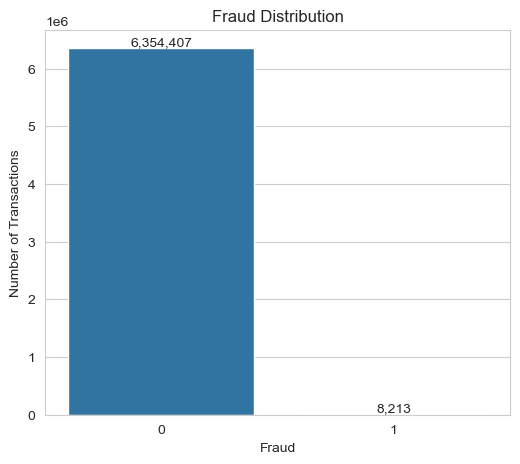

In [23]:
plt.figure(figsize=(6,5))
ax = sns.countplot(x='isFraud', data=df)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v):,}" for v in container.datavalues])
plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")
plt.show()

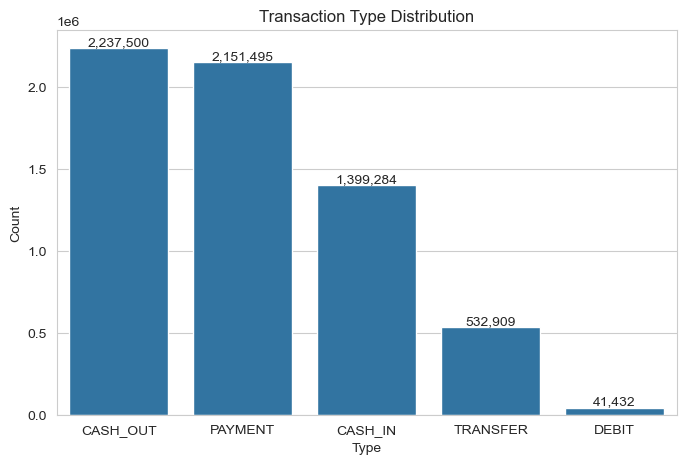

In [24]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v):,}" for v in container.datavalues])
plt.title("Transaction Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

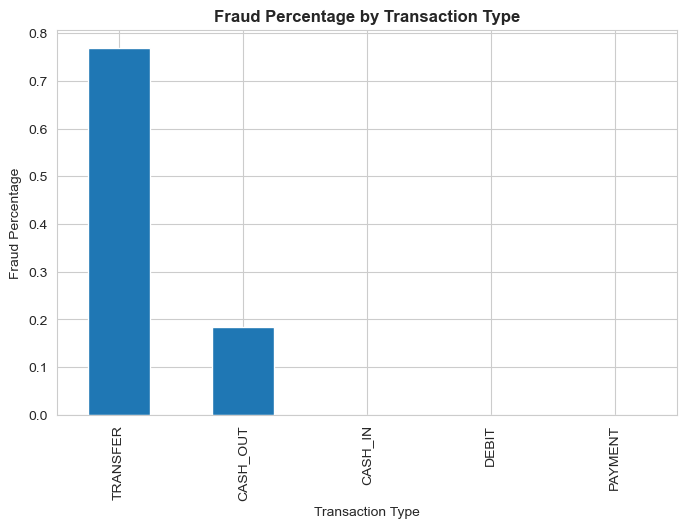

In [25]:
fraud_percent = pd.crosstab(df['type'], df['isFraud'], normalize='index') * 100
fraud_percent[1].sort_values(ascending=False).plot(kind='bar', figsize=(8,5))
plt.title("Fraud Percentage by Transaction Type", fontweight='bold')
plt.ylabel("Fraud Percentage")
plt.xlabel("Transaction Type")
plt.show()

## 6. Transaction Amount Analysis
Analyzing fraud transaction amounts, outliers, and applying a log transformation for skewed distribution.

In [26]:
# Create fraud transactions dataframe
df_fraud = df[df['isFraud'] == 1]

print("Fraud transactions:", len(df_fraud))
df_fraud.head()

Fraud transactions: 8213


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Orig_Balance_Suspect,Dest_Balance_Suspect
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,False,True
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0,False,False
251,1,TRANSFER,"2,806.00",C1420196421,"2,806.00",0.00,C972765878,0.00,0.00,1,0,False,True
252,1,CASH_OUT,"2,806.00",C2101527076,"2,806.00",0.00,C1007251739,"26,202.00",0.00,1,0,False,False
680,1,TRANSFER,"20,128.00",C137533655,"20,128.00",0.00,C1848415041,0.00,0.00,1,0,False,True


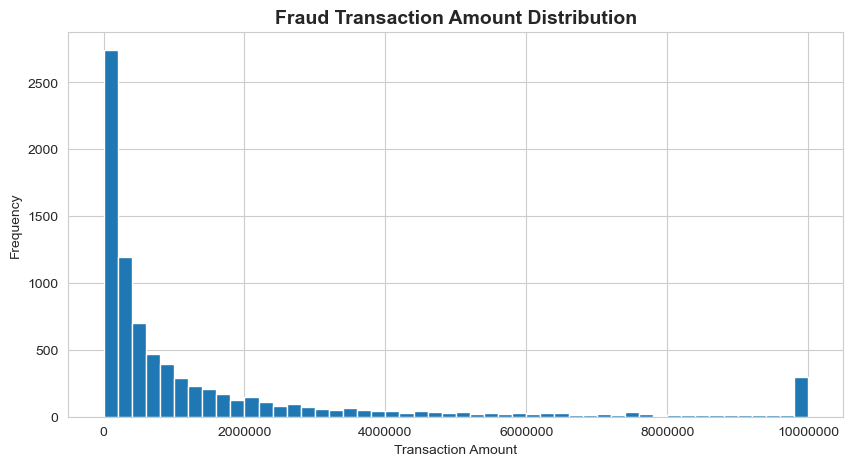

In [27]:
plt.figure(figsize=(10,5))

plt.hist(df_fraud['amount'], bins=50)

plt.title("Fraud Transaction Amount Distribution",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

In [28]:
# Dealing with Outliers

Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df['amount'] > upper_bound
print(f"IQR upper bound: {upper_bound:,.2f}")
print(f"Transactions above IQR bound: {outliers.sum():,} ({outliers.mean()*100:.2f}%)")

# The key diagnostic: is fraud over-represented among the "outliers"?
fraud_rate_outliers = df.loc[outliers, 'isFraud'].mean() * 100
fraud_rate_normal = df.loc[~outliers, 'isFraud'].mean() * 100
print(f"Fraud rate among amount outliers:     {fraud_rate_outliers:.3f}%")
print(f"Fraud rate among non-outlier amounts: {fraud_rate_normal:.3f}%")

IQR upper bound: 501,719.34
Transactions above IQR bound: 338,078 (5.31%)
Fraud rate among amount outliers:     1.140%
Fraud rate among non-outlier amounts: 0.072%


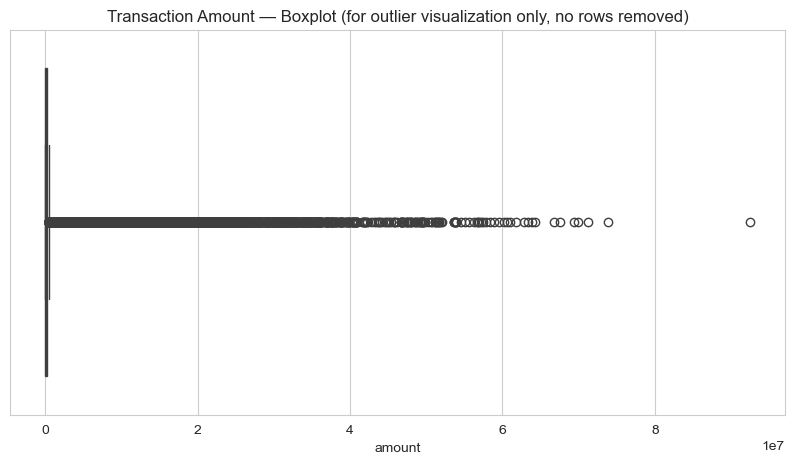

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['amount'])
plt.title("Transaction Amount — Boxplot (for outlier visualization only, no rows removed)")
plt.show()

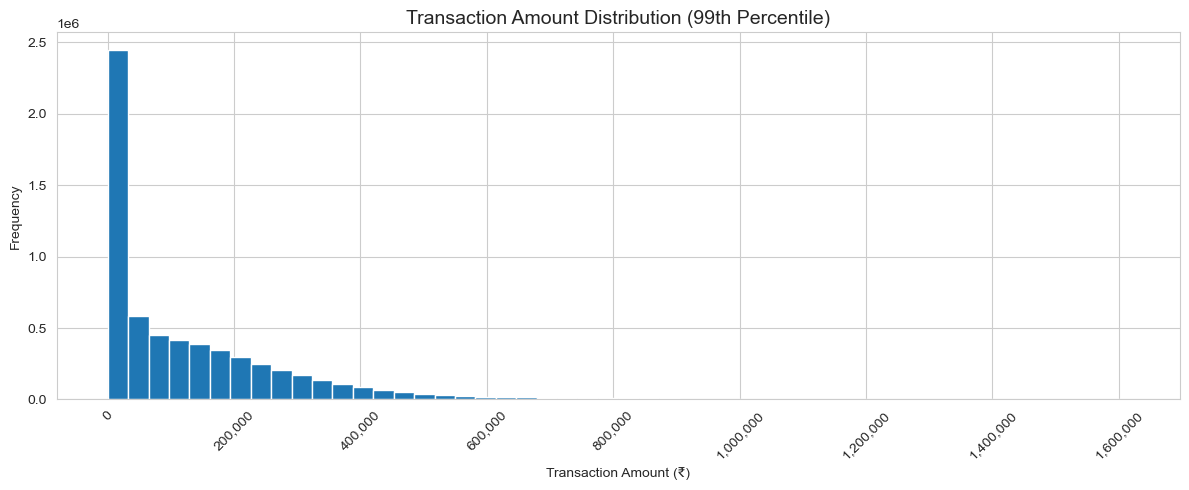

In [30]:
# Finding that 99% of transactions are far below the maximum value.

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

limit = df['amount'].quantile(0.99)

plt.figure(figsize=(12,5))

plt.hist(df[df['amount'] <= limit]['amount'], bins=50)

plt.title("Transaction Amount Distribution (99th Percentile)", fontsize=14)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

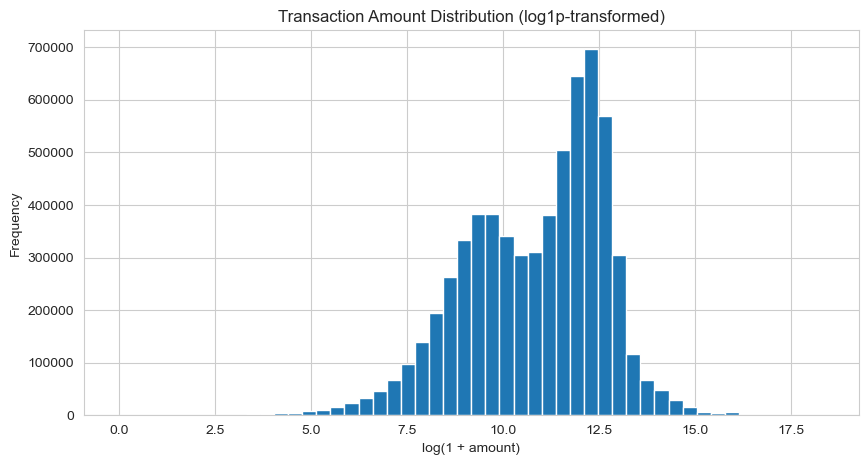

In [31]:
# Log-transform kept as a SEPARATE column — never overwrite the raw amount
df['amount_log'] = np.log1p(df['amount'])

plt.figure(figsize=(10,5))
plt.hist(df['amount_log'], bins=50)
plt.title("Transaction Amount Distribution (log1p-transformed)")
plt.xlabel("log(1 + amount)")
plt.ylabel("Frequency")
plt.show()

## 7. Balance Consistency & Correlation Analysis
Creating balance-discrepancy features and examining correlations between numeric variables.

In [32]:
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

df.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].describe().T

isFraud                            0             1
errorBalanceOrig count  6,354,407.00      8,213.00
                 mean     201,338.56     10,692.33
                 std      606,928.89    265,146.13
                 min           -0.01         -0.00
                 25%        3,034.31          0.00
                 50%       69,049.31          0.00
                 75%      249,953.43          0.00
                 max   92,445,516.64 10,000,000.00
errorBalanceDest count  6,354,407.00      8,213.00
                 mean           0.00          0.00
                 std            0.00          0.00
                 min            0.00          0.00
                 25%            0.00          0.00
                 50%            0.00          0.00
                 75%            0.00          0.00
                 max            0.00          0.00

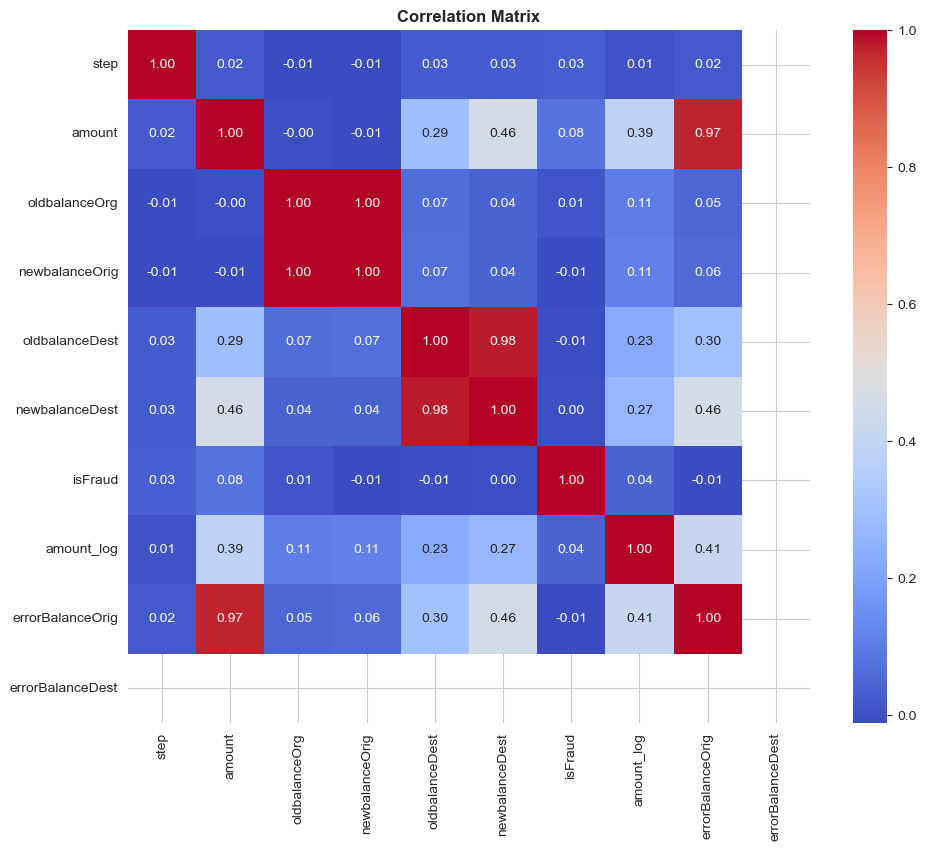

In [33]:
numeric = df.select_dtypes(include=['int64', 'int8', 'float64', 'float32']).drop(columns=['isFlaggedFraud'])
corr = numeric.corr()

plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix", fontweight='bold')
plt.show()

## 8. Key Finding — Balance Drain Pattern
Investigating whether account balance behavior is a stronger fraud signal than transaction amount.

In [34]:
# Does the transaction amount alone predict fraud, or is there a stronger signal hiding in how account balances behave?

df['Orig_Balance_Zeroed'] = (df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)

zero_rate = df.groupby('isFraud')['Orig_Balance_Zeroed'].mean() * 100
print(zero_rate)

isFraud
0   23.80
1   97.55
Name: Orig_Balance_Zeroed, dtype: float64


In [39]:
df['Orig_Balance_Zeroed'] = (df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)
zero_rate = df.groupby('isFraud')['Orig_Balance_Zeroed'].mean() * 100
print(zero_rate)

isFraud
0   23.80
1   97.55
Name: Orig_Balance_Zeroed, dtype: float64


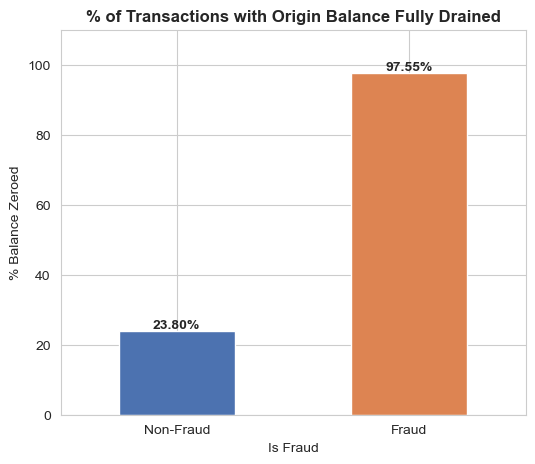

In [40]:
plt.figure(figsize=(6,5))
ax = zero_rate.plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title("% of Transactions with Origin Balance Fully Drained", fontweight='bold')
plt.xlabel("Is Fraud")
plt.ylabel("% Balance Zeroed")
plt.xticks([0,1], ['Non-Fraud','Fraud'], rotation=0)
for i, v in enumerate(zero_rate):
    ax.text(i, v+1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.ylim(0,110)
plt.show()

In [41]:
# 97.55% of fraudulent transactions completely drain the origin account balance to zero, compared to just 23.80% of legitimate transactions. 
# This means account balance behavior is a far stronger and more reliable fraud signal than transaction amount alone 
# fraud isn't about how much money moves, it's about accounts being emptied out.

In [42]:
df.groupby('isFraud')['errorBalanceOrig'].agg(['median','std','mean'])

,median,std,mean
isFraud,,,
0,"69,049.31","606,928.89","201,338.56"
1,0.00,"265,146.13","10,692.33"


## 9. Key Finding — Existing Fraud Flagging System Performance
Evaluating how effectively the dataset's existing rule-based flagging system detects actual fraud.

In [43]:
flag_summary = df.groupby('isFlaggedFraud').agg(
    total_transactions=('isFraud','count'),
    actual_fraud=('isFraud','sum')
)
flag_summary['fraud_rate_pct'] = (flag_summary['actual_fraud'] / flag_summary['total_transactions'] * 100).round(4)
print(flag_summary)

# The key number: of all ACTUAL fraud, how much did the system catch?
total_fraud = df['isFraud'].sum()
caught_fraud = df[(df['isFraud']==1) & (df['isFlaggedFraud']==1)].shape[0]
missed_fraud = df[(df['isFraud']==1) & (df['isFlaggedFraud']==0)].shape[0]

print(f"Total actual fraud: {total_fraud}")
print(f"Flagged by system: {caught_fraud}")
print(f"Missed by system: {missed_fraud}")
print(f"System catch rate: {caught_fraud/total_fraud*100:.2f}%")

                total_transactions  actual_fraud  fraud_rate_pct
isFlaggedFraud                                                  
0                          6362604          8197            0.13
1                               16            16          100.00
Total actual fraud: 8213
Flagged by system: 16
Missed by system: 8197
System catch rate: 0.19%


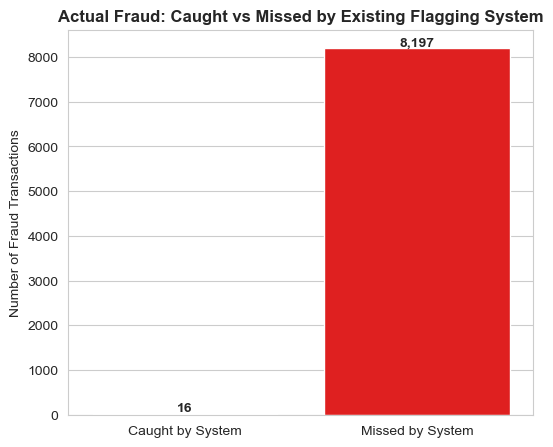

In [46]:
plt.figure(figsize=(6,5))
ax = sns.barplot(x=['Caught by System','Missed by System'], y=[caught_fraud, missed_fraud], palette=['green','red'])
plt.title("Actual Fraud: Caught vs Missed by Existing Flagging System", fontweight='bold')
plt.ylabel("Number of Fraud Transactions")
for i, v in enumerate([caught_fraud, missed_fraud]):
    ax.text(i, v+50, f"{v:,}", ha='center', fontweight='bold')
plt.show()

In [47]:
# Total rupee value of fraud that the system failed to flag
missed_amount = df[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 0)]['amount'].sum()
print(f"₹ missed by system: {missed_amount:,.2f}")

# For comparison, the rupee value the system DID catch
caught_amount = df[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1)]['amount'].sum()
print(f"₹ caught by system: {caught_amount:,.2f}")

# What % of total fraud value went undetected
missed_pct_value = missed_amount / (missed_amount + caught_amount) * 100
print(f"% of fraud value missed: {missed_pct_value:.2f}%")

₹ missed by system: 11,978,629,864.15
₹ caught by system: 77,785,563.69
% of fraud value missed: 99.35%


In [48]:
df_fe = df.copy()

## 10. Feature Engineering
Creating time-based, severity-based, and categorical features to support deeper analysis.

In [49]:
# Hour within a 24-hour cycle
df_fe['Transaction_Hour'] = df_fe['step'] % 24

# Simulation day number (step 1 = hour 1 of day 1)
df_fe['Transaction_Day'] = ((df_fe['step'] - 1) // 24) + 1

In [50]:
def time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df_fe['Time_period'] = df_fe['Transaction_Hour'].apply(time_period)
df_fe['Time_period'].value_counts()

Time_period
Afternoon    2249843
Evening      2221992
Morning      1196203
Night         694582
Name: count, dtype: int64

In [51]:
df_fe["Weekend"] = np.where((df_fe["Transaction_Day"] % 7).isin([6, 0]), "Yes", "No")
df_fe['Weekend'].value_counts()

Weekend
No     4607014
Yes    1755606
Name: count, dtype: int64

In [52]:
threshold = df_fe['amount'].quantile(0.95)
df_fe['High_Value'] = np.where(df_fe['amount'] >= threshold, 'Yes', 'No')
df_fe['High_Value'].value_counts()

High_Value
No     6044489
Yes     318131
Name: count, dtype: int64

In [53]:
df_fe['Dest_Balance_Change'] = df_fe['newbalanceDest'] - df_fe['oldbalanceDest']

In [54]:
def fraud_severity(row):
    if row['isFraud'] == 0:
        return "No Fraud"
    elif row['amount'] >= 500000:
        return "High"
    elif row['amount'] >= 100000:
        return "Medium"
    else:
        return "Low"

df_fe["Fraud_Severity"] = df_fe.apply(fraud_severity, axis=1)
df_fe['Fraud_Severity'].value_counts()

Fraud_Severity
No Fraud    6354407
High           3864
Medium         2642
Low            1707
Name: count, dtype: int64

In [56]:
def amount_category(amount):
    if amount < 1000:
        return "Small"
    elif amount < 10000:
        return "Medium"
    elif amount < 100000:
        return "Large"
    else:
        return "Very Large"

df_fe['Amount_Size'] = df_fe['amount'].apply(amount_category)
df_fe['Amount_Size'].value_counts()

Amount_Size
Very Large    2837364
Large         2239253
Medium        1143361
Small          142642
Name: count, dtype: int64

In [57]:
df_fe = df_fe.rename(columns={
    'nameOrig': 'Customer_ID',
    'nameDest': 'Recipient_ID'
})
df_fe.columns.tolist()

['step',
 'type',
 'amount',
 'Customer_ID',
 'oldbalanceOrg',
 'newbalanceOrig',
 'Recipient_ID',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'Orig_Balance_Suspect',
 'Dest_Balance_Suspect',
 'amount_log',
 'errorBalanceOrig',
 'errorBalanceDest',
 'Orig_Balance_Zeroed',
 'Transaction_Hour',
 'Transaction_Day',
 'Time_period',
 'Weekend',
 'High_Value',
 'Dest_Balance_Change',
 'Fraud_Severity',
 'Amount_Size']

## 11. Save Cleaned Dataset
Exporting the final feature-engineered dataset for SQL analysis and Power BI dashboarding.

In [58]:
print("Final shape:", df_fe.shape)
print("\nNull check:")
print(df_fe.isnull().sum().sum(), "total nulls")
print("\nDtypes:")
print(df_fe.dtypes)
df_fe.head()

Final shape: (6362620, 25)

Null check:
0 total nulls

Dtypes:
step                      int64
type                     object
amount                  float64
Customer_ID              object
oldbalanceOrg           float64
newbalanceOrig          float64
Recipient_ID             object
oldbalanceDest          float64
newbalanceDest          float64
isFraud                   int64
isFlaggedFraud            int64
Orig_Balance_Suspect       bool
Dest_Balance_Suspect       bool
amount_log              float64
errorBalanceOrig        float64
errorBalanceDest        float64
Orig_Balance_Zeroed        bool
Transaction_Hour          int64
Transaction_Day           int64
Time_period              object
Weekend                  object
High_Value               object
Dest_Balance_Change     float64
Fraud_Severity           object
Amount_Size              object
dtype: object


,step,type,amount,Customer_ID,oldbalanceOrg,newbalanceOrig,Recipient_ID,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Orig_Balance_Suspect,Dest_Balance_Suspect,amount_log,errorBalanceOrig,errorBalanceDest,Orig_Balance_Zeroed,Transaction_Hour,Transaction_Day,Time_period,Weekend,High_Value,Dest_Balance_Change,Fraud_Severity,Amount_Size
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0,False,False,9.19,0.00,0.00,False,1,1,Night,No,No,0.00,No Fraud,Medium
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0,False,False,7.53,0.00,0.00,False,1,1,Night,No,No,0.00,No Fraud,Medium
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,False,True,5.20,0.00,0.00,True,1,1,Night,No,No,0.00,Low,Small
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0,False,False,5.20,0.00,0.00,True,1,1,Night,No,No,0.00,Low,Small
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0,False,False,9.36,0.00,0.00,False,1,1,Night,No,No,0.00,No Fraud,Large


In [59]:
CLEAN_DATA_PATH = "C:/Users/abhis/OneDrive/Documents/Banking Fraud Analytics/Data/Clean Data/Banking_clean.csv"

df_fe.to_csv(CLEAN_DATA_PATH, index=False)
print(f"Saved {df_fe.shape[0]:,} rows to {CLEAN_DATA_PATH}")

Saved 6,362,620 rows to C:/Users/abhis/OneDrive/Documents/Banking Fraud Analytics/Data/Clean Data/Banking_clean.csv
